# **Analyse du diabète (Pima Indians Dataset)**

## **1.Importation des bibliothèques**

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay


In [2]:
import warnings
warnings.filterwarnings('ignore')

## **2.Chargement des données**

In [3]:
df = pd.read_csv("/content/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## **3. Nettoyage des données**

**3.1 Détection des valeurs incohérentes**

In [8]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
df[cols] = df[cols].replace(0, np.nan)

In [9]:
df.isnull().sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**3.2 Imputation**

In [10]:
df.fillna(df.median(), inplace=True)

In [11]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**3.3 Outliers (IQR)**

In [12]:
for col_name in cols:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    outliers = df[(df[col_name] < borne_basse) | (df[col_name] > borne_haute)]
    print(f"Number of outliers in '{col_name}':{len(outliers)}")

Number of outliers in 'Pregnancies':14
Number of outliers in 'Glucose':0
Number of outliers in 'BloodPressure':14
Number of outliers in 'SkinThickness':87
Number of outliers in 'Insulin':346
Number of outliers in 'BMI':8
Number of outliers in 'DiabetesPedigreeFunction':29
Number of outliers in 'Age':9


**3.4 Outliers avec Z-score**

In [13]:
z = np.abs(stats.zscore(df[['Glucose','BMI','Age']]))
df = df[(z < 3).all(axis=1)]

 **3.5 Suppression des doublons**

In [14]:
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

Nombre de lignes dupliquées : 0


In [15]:
print(f"Taille du dataframe avant suppression des doublons : {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Taille du dataframe après suppression des doublons : {df.shape}")

Taille du dataframe avant suppression des doublons : (758, 9)
Taille du dataframe après suppression des doublons : (758, 9)


# **4. Analyse exploratoire (EDA)**

## **Histogrammes**

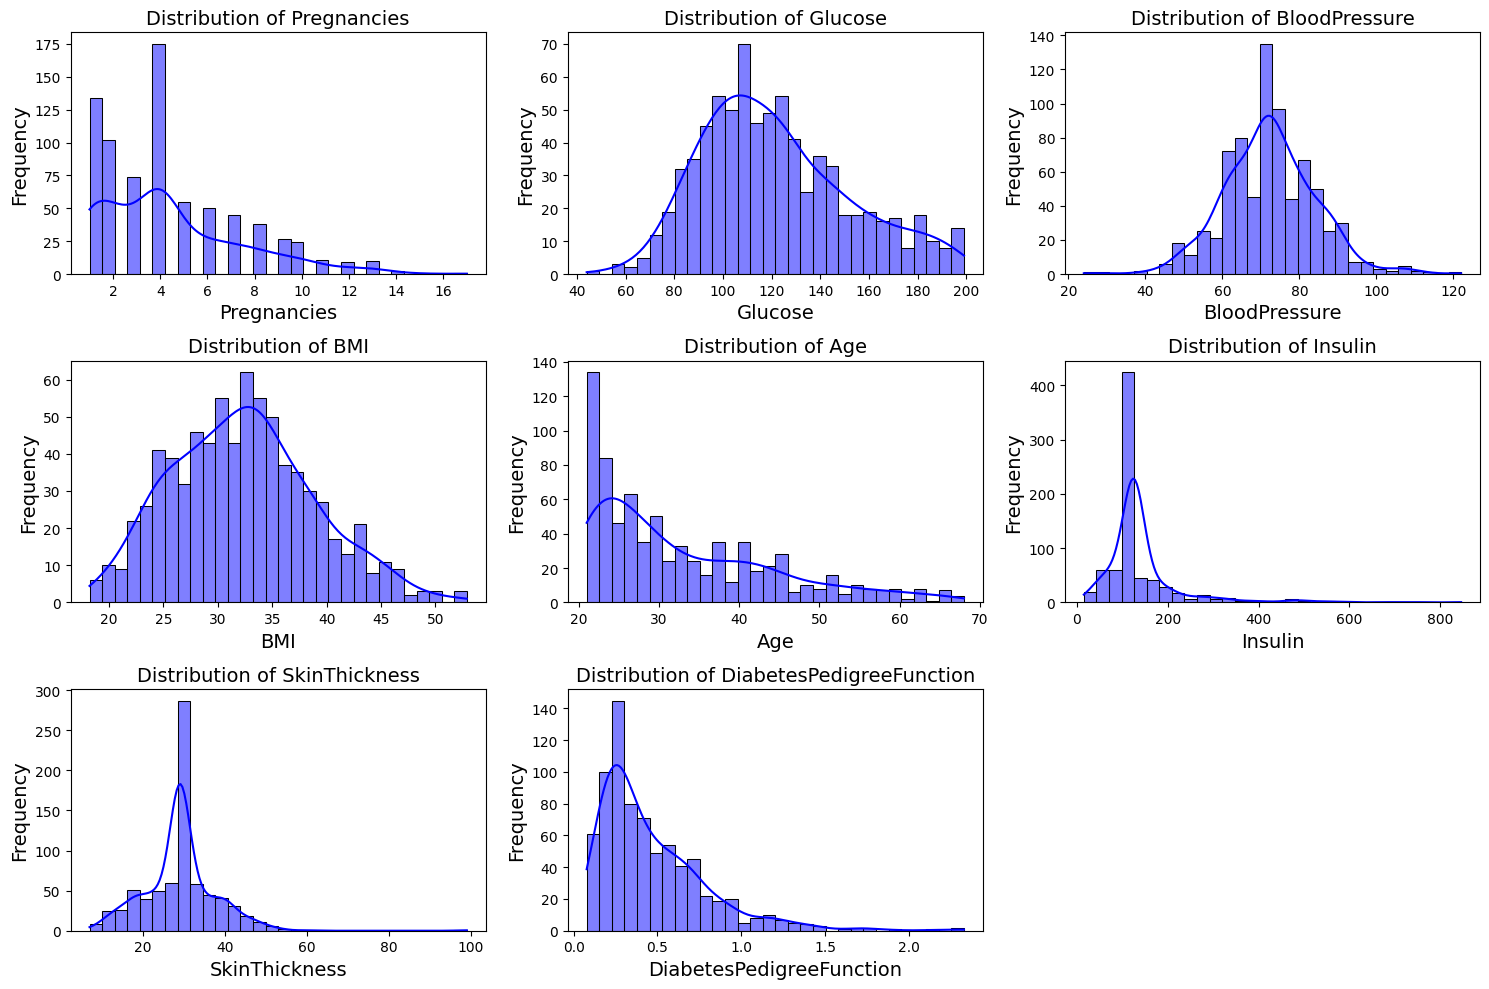

In [16]:
plt.figure(figsize=(15, 10))
columns_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction']

for i, col in enumerate(columns_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)

plt.tight_layout()
plt.show()

## **Boxplot**

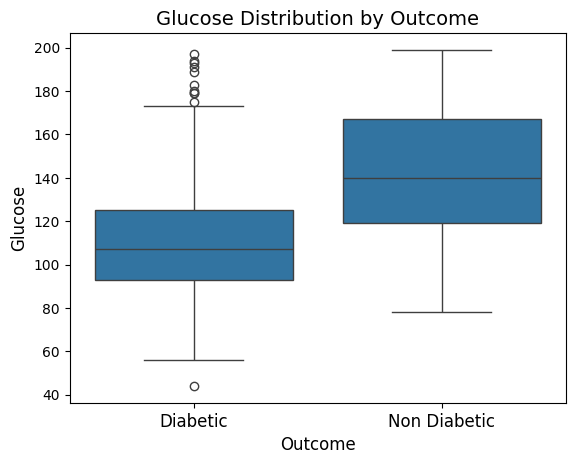

In [17]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.xticks([0, 1],['Diabetic', 'Non Diabetic'], fontsize=12)
plt.xlabel("Outcome", fontsize=12)
plt.ylabel("Glucose", fontsize=12)
plt.title("Glucose Distribution by Outcome", fontsize=14)
plt.show()

## **Heatmap corrélation**

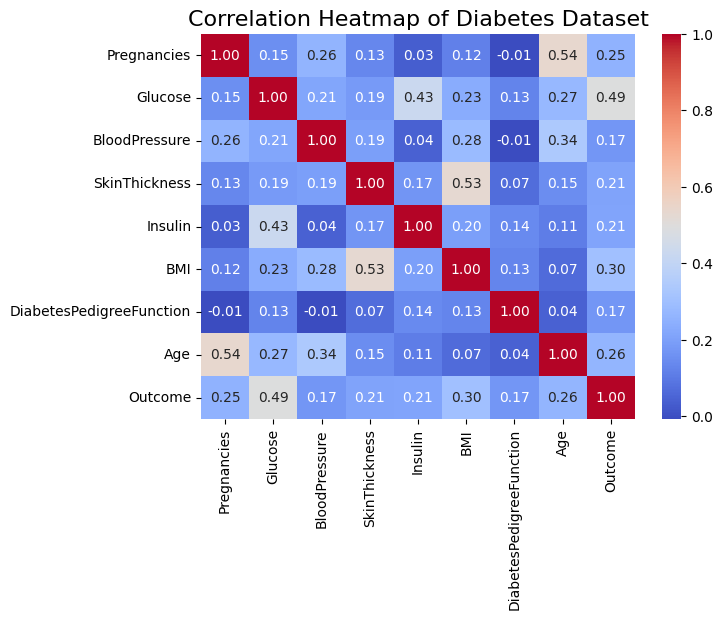

In [18]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10})
plt.title("Correlation Heatmap of Diabetes Dataset", fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.show()

# **5. Segmentation**

In [19]:
diab = df[df["Outcome"] == 1]
non_diab = df[df["Outcome"] == 0]

print(f"Les diabétique :\n  Glucose: {diab['Glucose'].mean():.2f}\n  BMI: {diab['BMI'].mean():.2f}\n  Age: {diab['Age'].mean():.2f}")
print(f"Les non diabétique :\n  Glucose: {non_diab['Glucose'].mean():.2f}\n  BMI: {non_diab['BMI'].mean():.2f}\n  Age: {non_diab['Age'].mean():.2f}")

Les diabétique :
  Glucose: 142.16
  BMI: 35.04
  Age: 37.12
Les non diabétique :
  Glucose: 110.50
  BMI: 30.87
  Age: 30.87


In [20]:
print(f"shape des diabétique : {diab.shape}")
print(f"shape des non diabétique : {non_diab.shape}")

shape des diabétique : (263, 9)
shape des non diabétique : (495, 9)


# **6. Test statistique (t-test)**

In [21]:
t_stat, p_value = stats.ttest_ind(diab["Glucose"], non_diab["Glucose"])

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 15.650581919667635
p-value: 4.935588506081172e-48


# **7. Analyse BMI et Age**

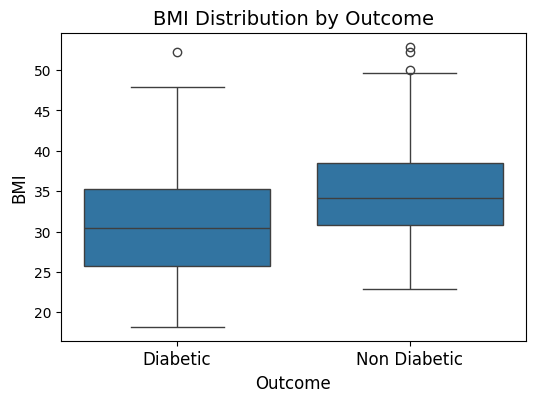

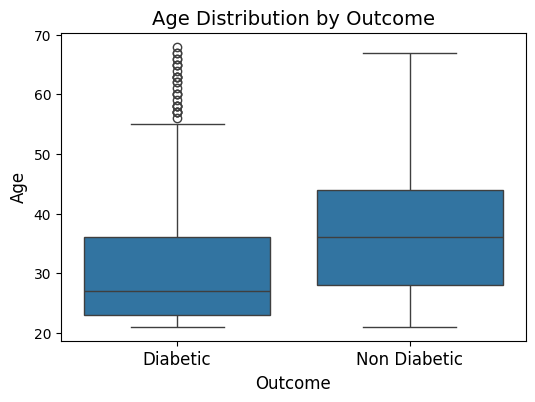

In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.xticks([0, 1],['Diabetic', 'Non Diabetic'], fontsize=12)
plt.xlabel("Outcome", fontsize=12)
plt.ylabel("BMI", fontsize=12)
plt.title("BMI Distribution by Outcome", fontsize=14)
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="Outcome", y="Age", data=df)
plt.xticks([0, 1],['Diabetic', 'Non Diabetic'], fontsize=12)
plt.xlabel("Outcome", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.title("Age Distribution by Outcome", fontsize=14)
plt.show()

# **8. Valeurs seuils (Decision Tree)**

In [23]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

from sklearn.tree import export_text
rules = export_text(tree, feature_names=list(X.columns))
print(rules)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- class: 0
|--- Glucose >  127.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 145.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  145.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 157.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  157.50
|   |   |   |--- class: 1



# **9. Machine Learning (Logistic Regression)**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## **Normalisation**

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Modèle**

In [26]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

# **Evaluation**

Accuracy: 0.7632

Classification Report:
              precision    recall  f1-score   support

        Sain       0.79      0.87      0.83       102
      Malade       0.68      0.54      0.60        50

    accuracy                           0.76       152
   macro avg       0.73      0.71      0.72       152
weighted avg       0.76      0.76      0.76       152

AUC-ROC : 0.8375


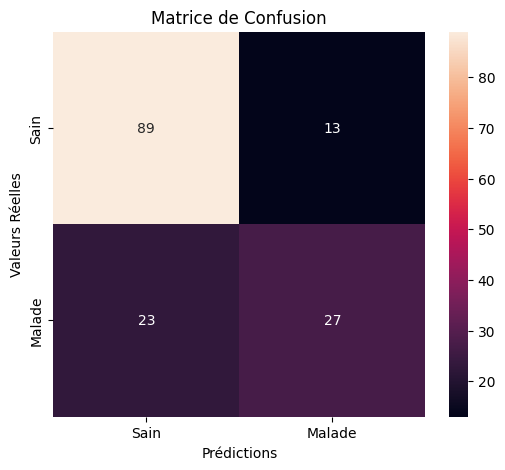

<Figure size 700x600 with 0 Axes>

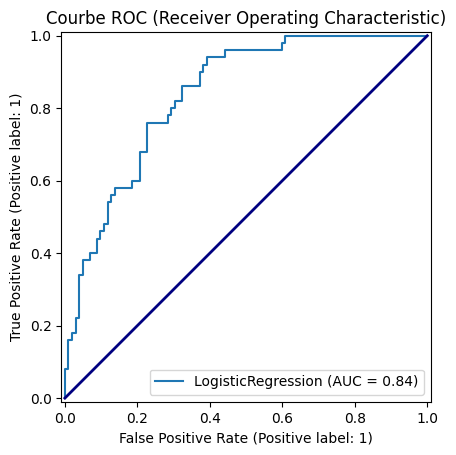

In [27]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Sain", "Malade"]))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC : {auc_score:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True,
            xticklabels=['Sain', 'Malade'],
            yticklabels=['Sain', 'Malade'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.show()

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_estimator(model, X_test, y_test,)

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="-")

plt.title("Courbe ROC (Receiver Operating Characteristic)")
plt.show()

# **Importance des variables**

In [28]:
coeff = pd.DataFrame(model.coef_[0], index=X.columns, columns=["Importance"])
print(coeff.sort_values(by="Importance", ascending=False))

                          Importance
Glucose                     1.157023
BMI                         0.532540
Pregnancies                 0.422639
DiabetesPedigreeFunction    0.278100
Age                         0.239583
SkinThickness               0.079253
Insulin                    -0.094473
BloodPressure              -0.191950


## **10. Prédiction avec le modèle entraîné**

In [29]:
new_data = pd.DataFrame({
    'Pregnancies': [2, 5, 1, 8],
    'Glucose': [110, 160, 90, 190],
    'BloodPressure': [70, 80, 60, 75],
    'SkinThickness': [25, 35, 20, 40],
    'Insulin': [100, 180, 50, 300],
    'BMI': [28.0, 38.0, 22.0, 42.0],
    'DiabetesPedigreeFunction': [0.2, 0.6, 0.15, 0.9],
    'Age': [25, 45, 22, 55]
})

print("Nouvelles données pour la prédiction:")
display(new_data)

new_data_scaled = scaler.transform(new_data)

predictions = model.predict(new_data_scaled)
prediction_probabilities = model.predict_proba(new_data_scaled)

for i in range(len(new_data)):
    print(f"\nPatient {i+1}:")
    print(f"  Profil: {new_data.iloc[i].to_dict()}")
    print(f"  Prédiction: {'Diabétique' if predictions[i] == 1 else 'Non Diabétique'}")
    print(f"  Probabilité d'être Diabétique: {prediction_probabilities[i][1]:.4f}")
    print(f"  Probabilité de ne pas être Diabétique: {prediction_probabilities[i][0]:.4f}")

Nouvelles données pour la prédiction:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,110,70,25,100,28.0,0.20,25
1,5,160,80,35,180,38.0,0.60,45
2,1,90,60,20,50,22.0,0.15,22
3,8,190,75,40,300,42.0,0.90,55



Patient 1:
  Profil: {'Pregnancies': 2.0, 'Glucose': 110.0, 'BloodPressure': 70.0, 'SkinThickness': 25.0, 'Insulin': 100.0, 'BMI': 28.0, 'DiabetesPedigreeFunction': 0.2, 'Age': 25.0}
  Prédiction: Non Diabétique
  Probabilité d'être Diabétique: 0.0877
  Probabilité de ne pas être Diabétique: 0.9123

Patient 2:
  Profil: {'Pregnancies': 5.0, 'Glucose': 160.0, 'BloodPressure': 80.0, 'SkinThickness': 35.0, 'Insulin': 180.0, 'BMI': 38.0, 'DiabetesPedigreeFunction': 0.6, 'Age': 45.0}
  Prédiction: Diabétique
  Probabilité d'être Diabétique: 0.8041
  Probabilité de ne pas être Diabétique: 0.1959

Patient 3:
  Profil: {'Pregnancies': 1.0, 'Glucose': 90.0, 'BloodPressure': 60.0, 'SkinThickness': 20.0, 'Insulin': 50.0, 'BMI': 22.0, 'DiabetesPedigreeFunction': 0.15, 'Age': 22.0}
  Prédiction: Non Diabétique
  Probabilité d'être Diabétique: 0.0247
  Probabilité de ne pas être Diabétique: 0.9753

Patient 4:
  Profil: {'Pregnancies': 8.0, 'Glucose': 190.0, 'BloodPressure': 75.0, 'SkinThickness': 4